# Visualise TCR:pMHC Contact Maps

This notebook visualises the contact maps between TCRs and pMHCs. CDR loops and peptides are standardised by position relative to the apex of the loop. In cases where the entities length is even, the position to the left of the middle of the loop is taken as the centre.

In [1]:
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tcr_antigen_prediction.data.imgt_numbering import assign_helix

In [2]:
CDR_1_LENGTH = 8
CDR_2_LENGTH = 8
CDR_3_LENGTH = 24

PEPTIDE_LENGTH = 12

In [3]:
contact_map = pd.read_csv('data/interim/tcr_pmhc_contacts.csv')

In [4]:
contact_map['class_i_pad_pos'] = None
contact_map.loc[contact_map['relative_pos_centre_pmhc'].notna(), 'class_i_pad_pos'] = contact_map[
    contact_map['relative_pos_centre_pmhc'].notna()
]['relative_pos_centre_pmhc'].map(
    lambda pos: pos + PEPTIDE_LENGTH // 2 - 1,
)

In [5]:
contact_map['residue_seq_id_pmhc'] = None
contact_map.loc[contact_map['resi_pmhc'].notna(), 'residue_seq_id_pmhc'] = contact_map[
    contact_map['resi_pmhc'].notna()
]['resi_pmhc'].map(
    lambda resi: int(''.join([char for char in resi if char.isnumeric()])),
)

In [6]:
contact_map['chain_type_tcr'] = contact_map['cdr_type'].str[4:]
contact_map['cdr'] = contact_map['cdr_type'].str[3].apply(int)

In [7]:
contact_map['cdr_pad_pos'] = None

for cdr_num, cdr_length in enumerate((CDR_1_LENGTH, CDR_2_LENGTH, CDR_3_LENGTH), 1):
    selection = (contact_map['cdr'] == cdr_num) & contact_map['relative_pos_centre_tcr'].notna()
    contact_map.loc[selection, 'cdr_pad_pos'] = contact_map[selection]['relative_pos_centre_tcr'].map(
        lambda pos, cdr_length=cdr_length: pos + cdr_length // 2 - 1,
    )

In [8]:
def gaussian_2d(values: np.ndarray, means: np.ndarray, cov: np.ndarray) -> np.ndarray:
    return (1 / np.sqrt(((2 * np.pi) ** 2) * np.linalg.det(cov))) * np.exp(
        -1 / 2 * (values - means).T @ np.linalg.inv(cov) @ (values - means)
    )

## TCR:Peptide interactions

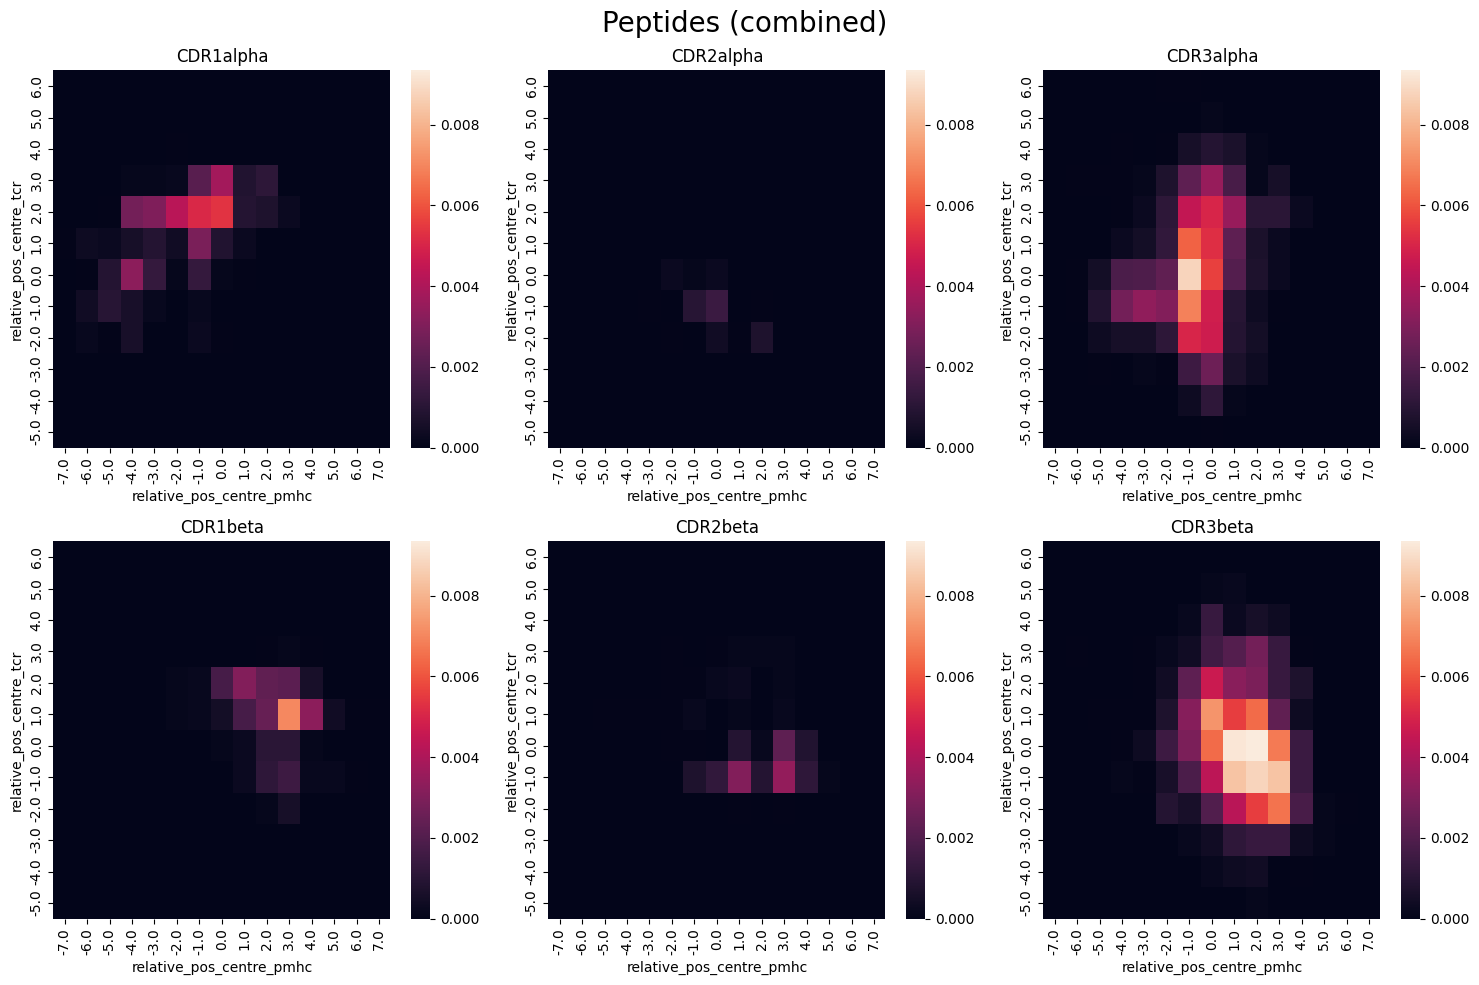

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptides (combined)', fontsize=20)
fig_data = contact_map[contact_map['chain_type_pmhc'] == 'antigen_chain']
fig_data = (
    fig_data.groupby(
        ['chain_type_tcr', 'cdr', 'relative_pos_centre_tcr', 'relative_pos_centre_pmhc'],
    )['proportion']
    .agg('sum')
    .reset_index()
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()


for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

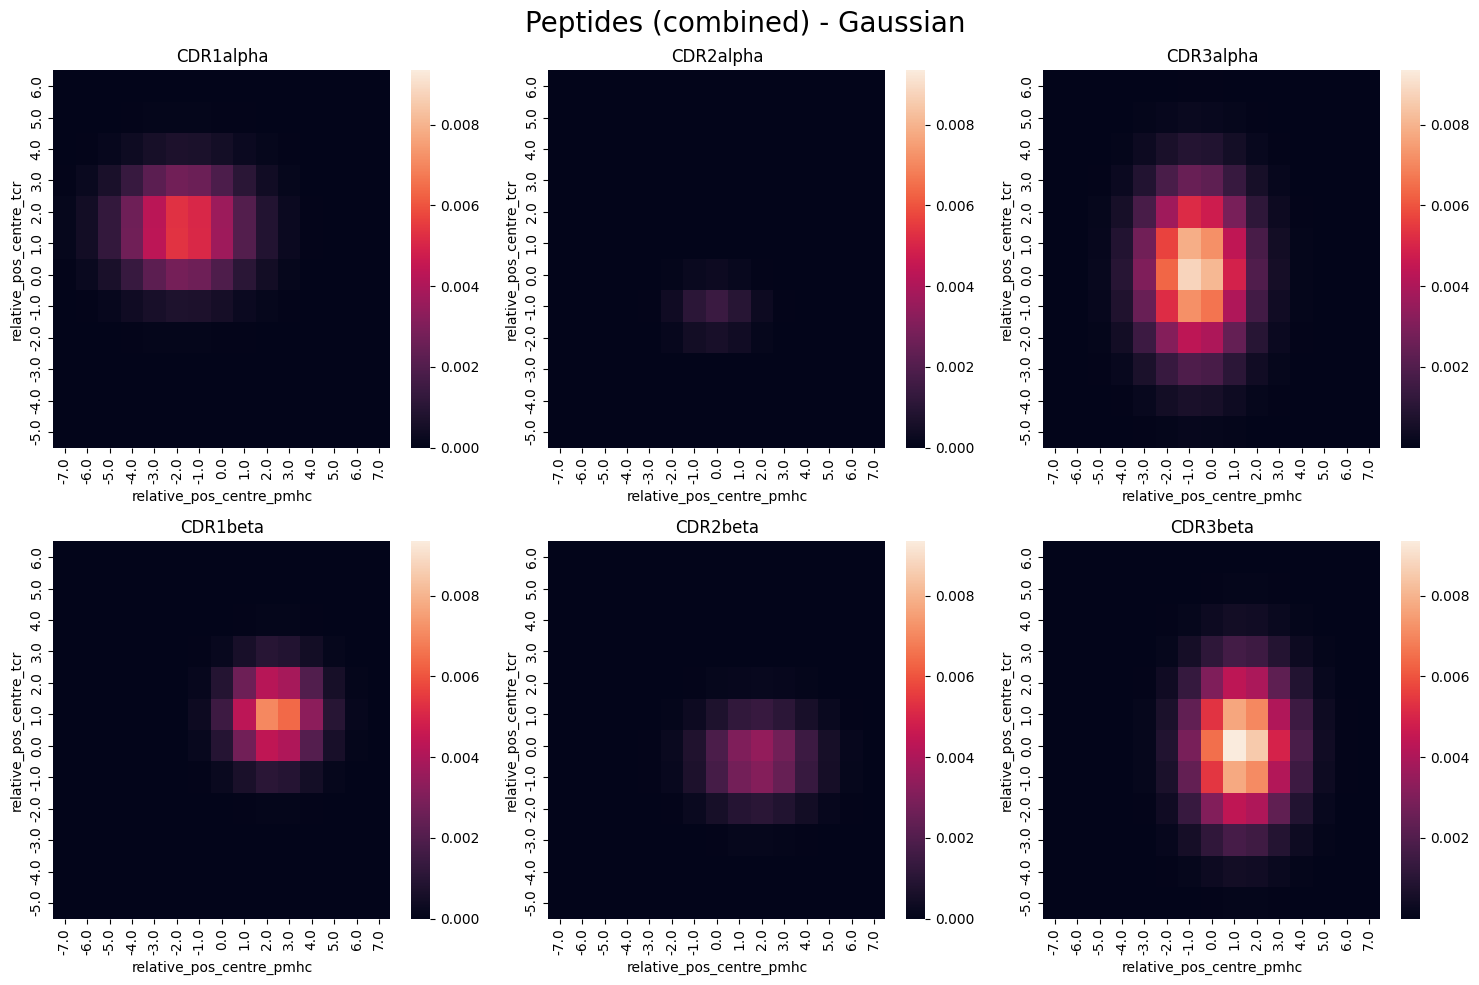

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptides (combined) - Gaussian', fontsize=20)
fig_data = contact_map[contact_map['chain_type_pmhc'] == 'antigen_chain']
fig_data = (
    fig_data.groupby(
        ['chain_type_tcr', 'cdr', 'relative_pos_centre_tcr', 'relative_pos_centre_pmhc'],
    )['proportion']
    .agg('sum')
    .reset_index()
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

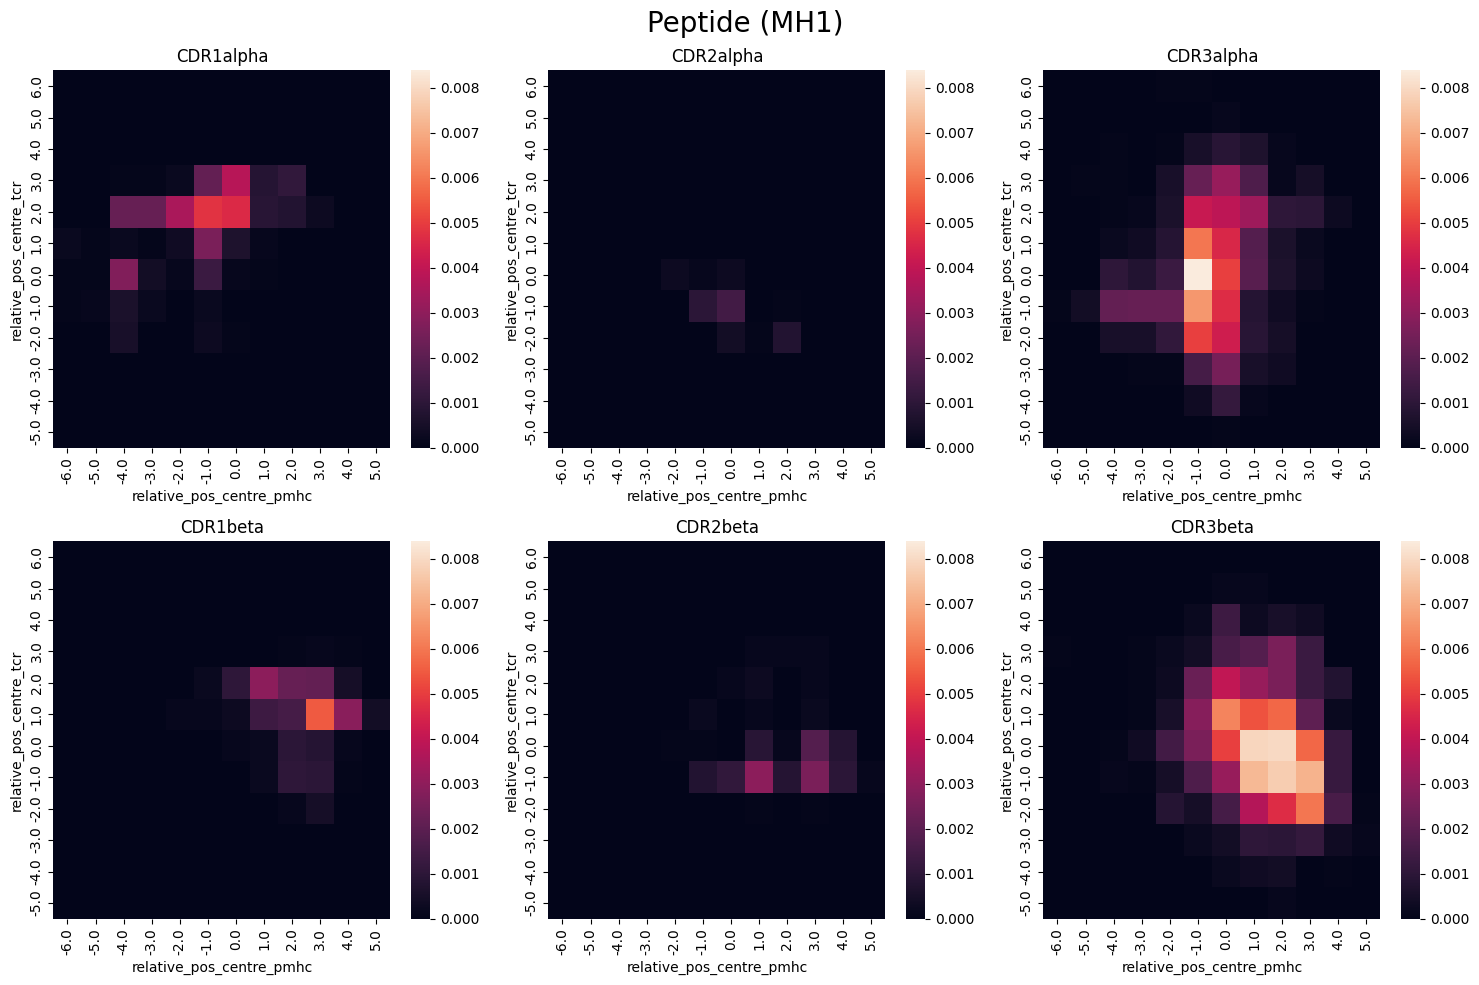

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH1)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

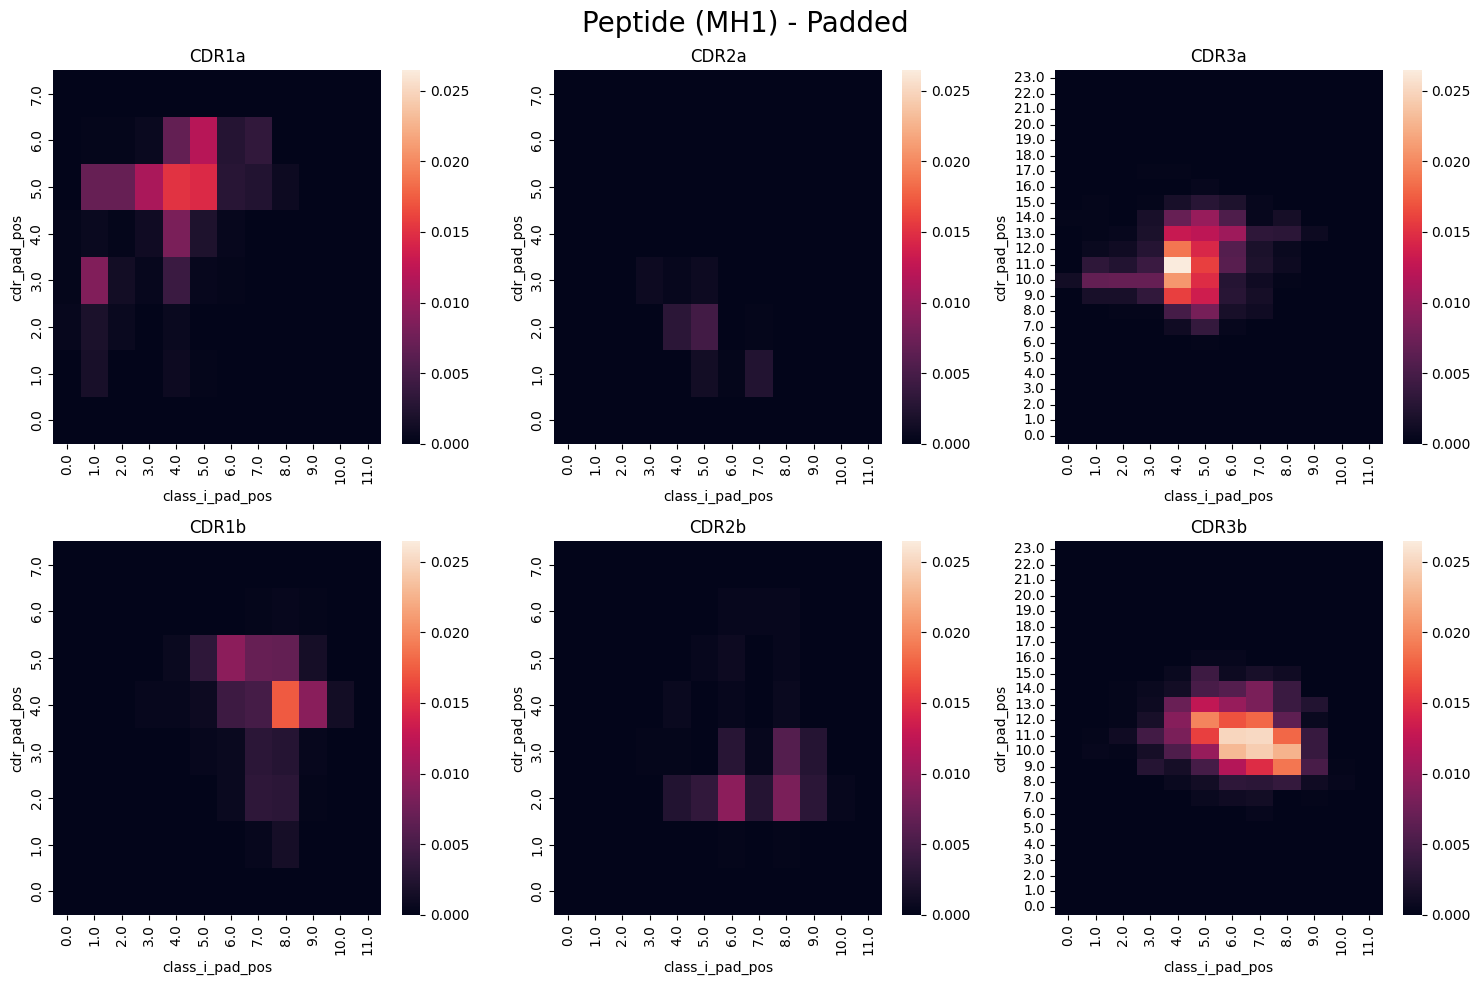

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH1) - Padded', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, (cdr_num, cdr_length) in enumerate(((1, CDR_1_LENGTH), (2, CDR_2_LENGTH), (3, CDR_3_LENGTH))):
        y_labels = np.arange(cdr_length)
        x_labels = np.arange(PEPTIDE_LENGTH)

        selected_data = fig_data[
            (fig_data['chain_type_tcr'] == chain_type)
            & (fig_data['cdr'] == cdr_num)
            & (fig_data['cdr_pad_pos'] >= 0)
            & (fig_data['cdr_pad_pos'] < cdr_length)
            & (fig_data['class_i_pad_pos'] >= 0)
            & (fig_data['class_i_pad_pos'] < PEPTIDE_LENGTH)
        ]

        table = selected_data.pivot_table(
            index='cdr_pad_pos',
            columns='class_i_pad_pos',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        tables[i][j] = table

# Normalise
total = 0
for i in range(2):
    for j in range(3):
        total += tables[i][j].sum().sum()

for i in range(2):
    for j in range(3):
        tables[i][j] = tables[i][j].map(lambda val, total=total: val / total)

# Find maximum
maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

# Plot
for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr_num in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr_num}{chain_type[0]}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

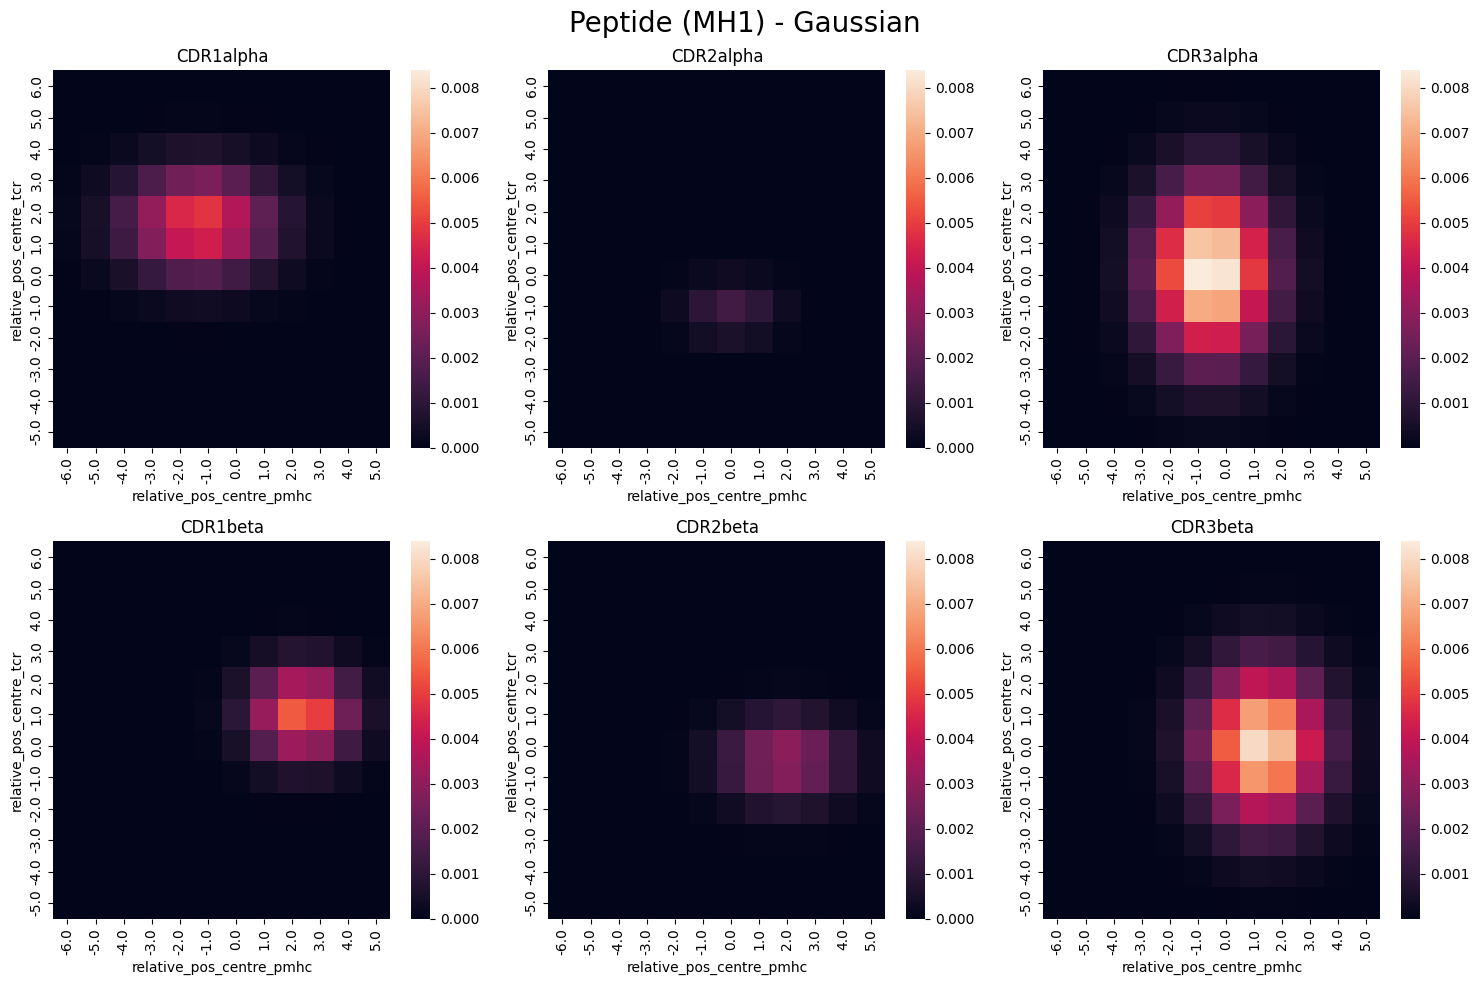

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH1) - Gaussian', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

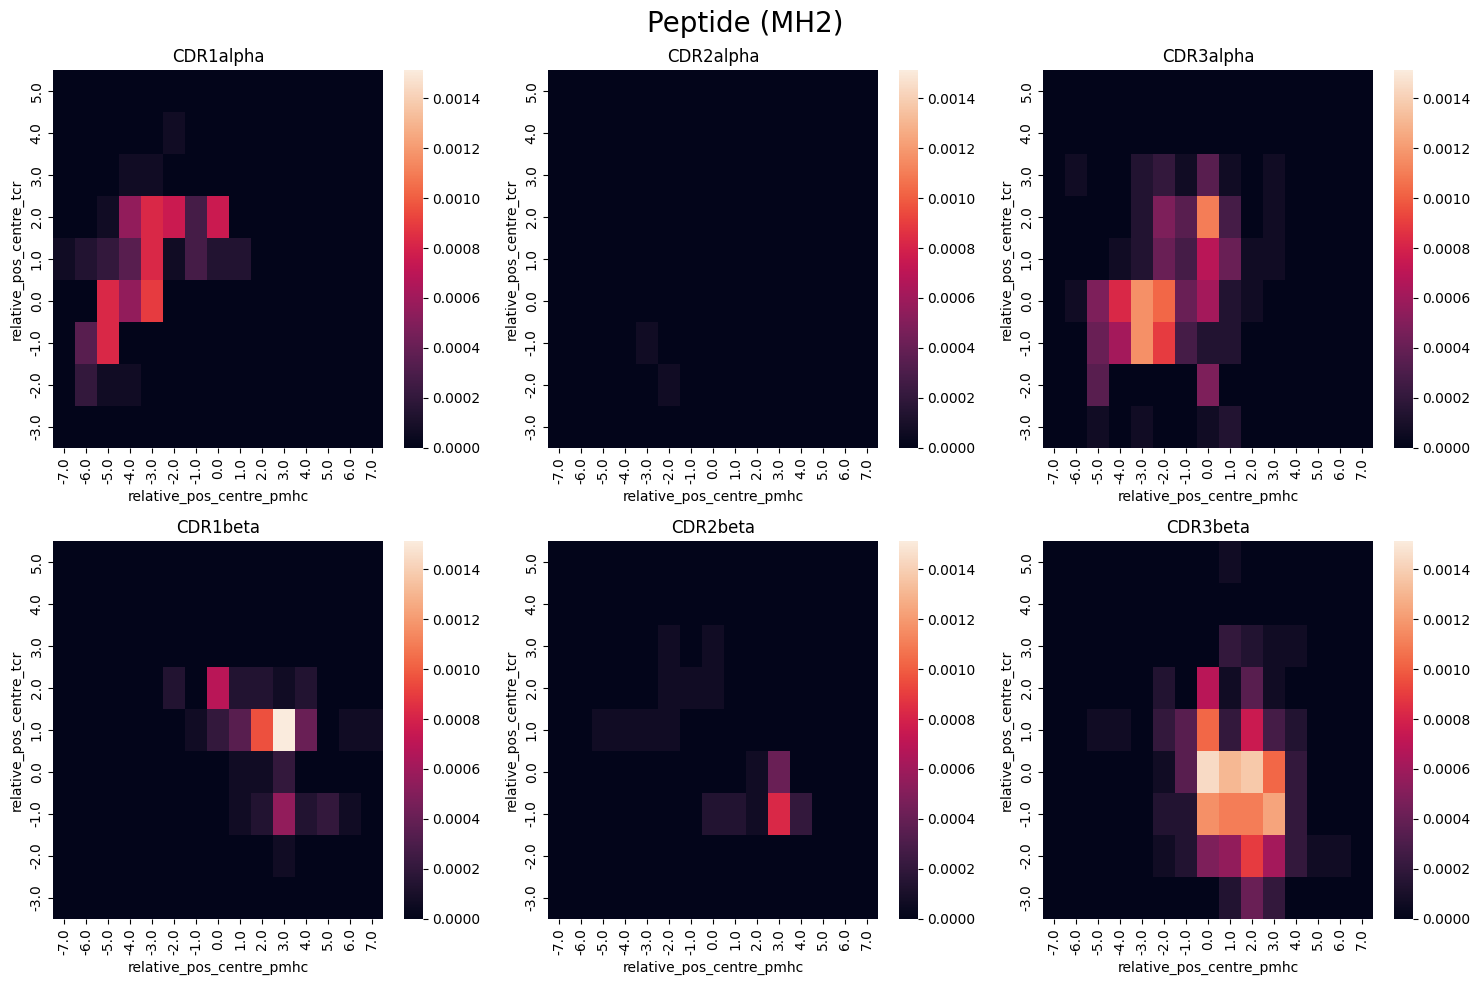

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH2)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

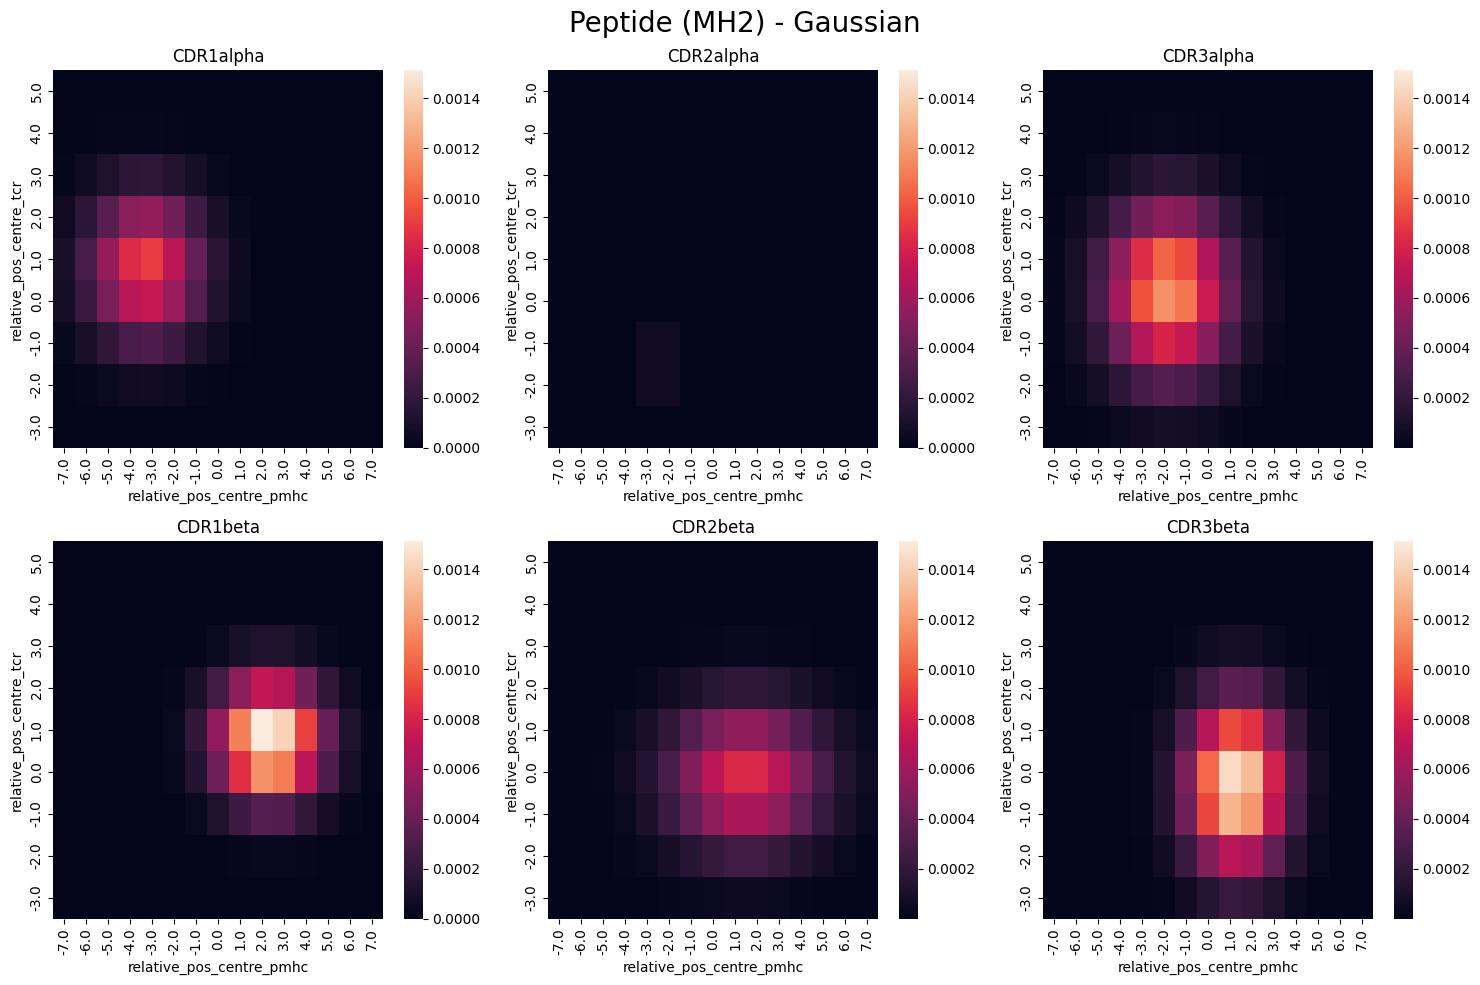

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH2) - Gaussian', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

## TCR:MHC Interactions

In [16]:
with open('data/interim/mhc_pseudo_seq_imgt_positions.json', 'r') as fh:
    mhc_pseudo_seqeunces = json.load(fh)

mhc_pseudo_pos = [(resi, helix[0]) for helix in ('alpha', 'beta') for resi in mhc_pseudo_seqeunces[helix]]
mhc_pseudo_pos

[('62', 'a'),
 ('63', 'a'),
 ('65', 'a'),
 ('66', 'a'),
 ('68', 'a'),
 ('69', 'a'),
 ('70', 'a'),
 ('72', 'a'),
 ('73', 'a'),
 ('75', 'a'),
 ('76', 'a'),
 ('79', 'a'),
 ('58', 'b'),
 ('61A', 'b'),
 ('62', 'b'),
 ('63', 'b'),
 ('65', 'b'),
 ('66', 'b'),
 ('67', 'b'),
 ('69', 'b'),
 ('70', 'b'),
 ('72', 'b'),
 ('72A', 'b'),
 ('73', 'b'),
 ('76', 'b'),
 ('77', 'b')]

In [ ]:
contact_map['imgt_pmhc'] = None


shortened_resi = contact_map[contact_map['resi_pmhc'].notna()]['resi_pmhc'].map(
    lambda resi: resi[2:] if re.match(r'\d\d\d\d[A-Za-z]?', resi) else resi,
)

mhc_helix = contact_map[contact_map['resi_pmhc'].notna()].apply(
    lambda row: assign_helix(row.mhc_type, row.chain_type_pmhc, row.resi_pmhc)[0],
    axis=1,
)

contact_map.loc[contact_map['resi_pmhc'].notna(), 'imgt_pmhc'] = pd.concat(
    [shortened_resi.to_frame(), mhc_helix.to_frame()],
    axis=1,
).apply(tuple, axis=1)

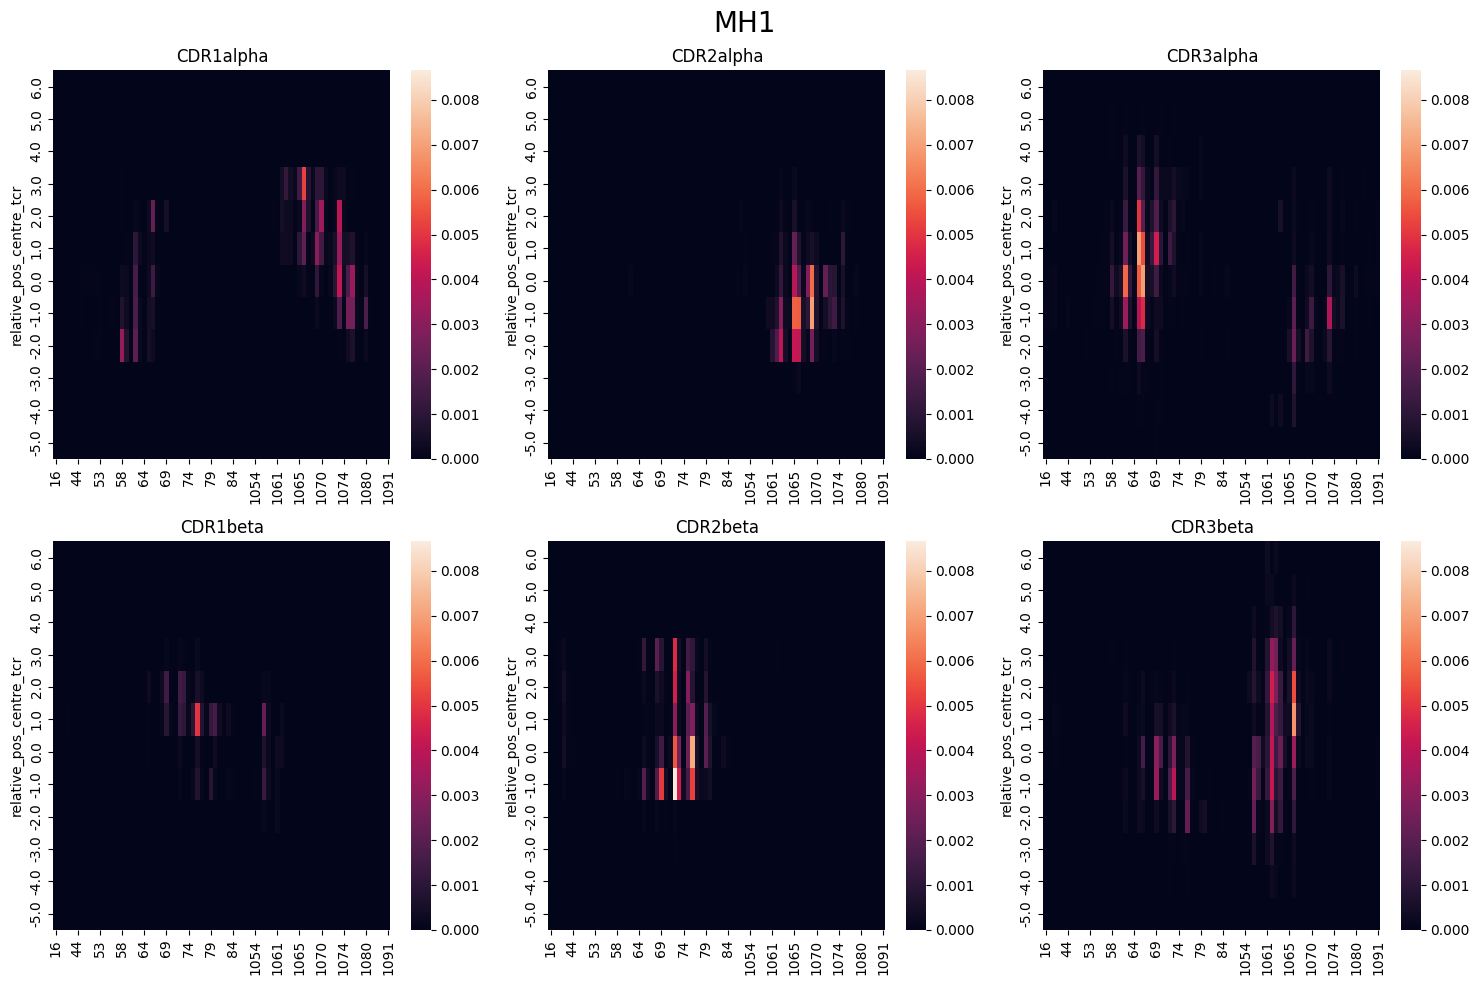

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('MH1', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] != 'antigen_chain')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

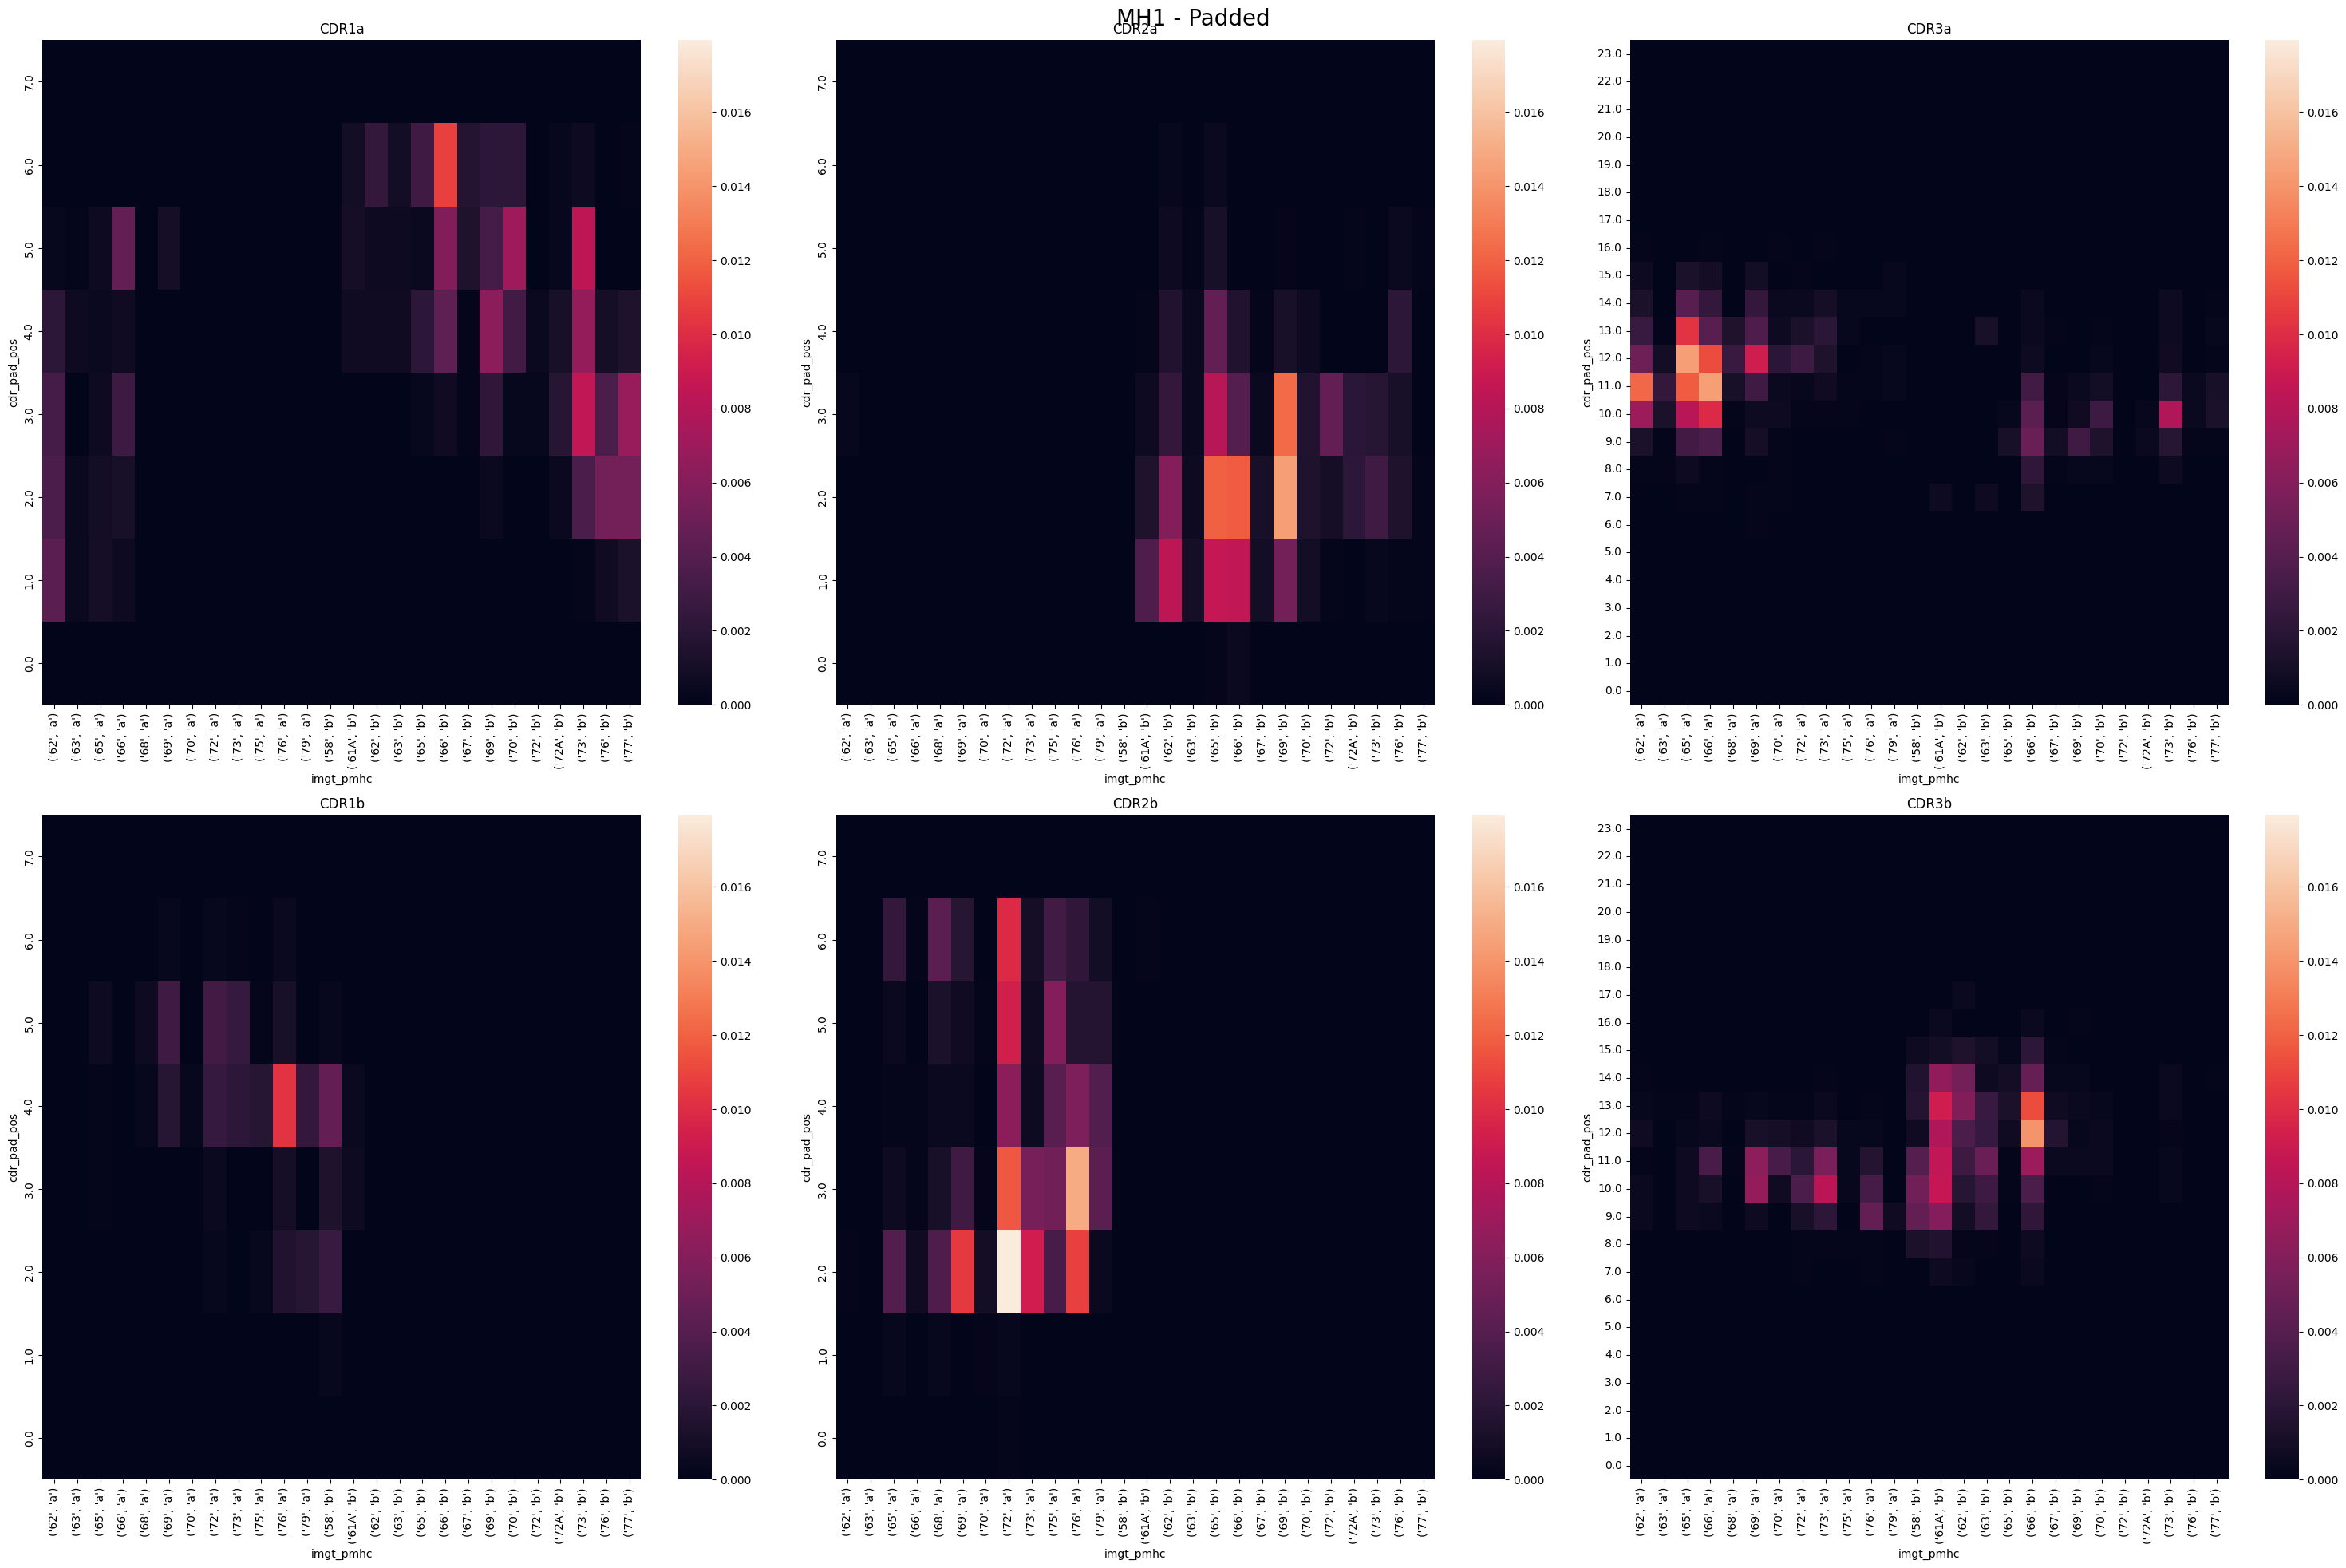

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(30, 20))

fig.suptitle('MH1 - Padded', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] != 'antigen_chain')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

maximum = fig_data['proportion'].max()

tables = [[None, None, None], [None, None, None]]
for i, chain_type in enumerate(('alpha', 'beta')):
    for j, (cdr_num, cdr_length) in enumerate(((1, CDR_1_LENGTH), (2, CDR_2_LENGTH), (3, CDR_3_LENGTH))):
        y_labels = np.arange(cdr_length)
        x_labels = mhc_pseudo_pos

        selected_data = fig_data[
            (fig_data['chain_type_tcr'] == chain_type)
            & (fig_data['cdr'] == cdr_num)
            & fig_data['imgt_pmhc'].isin(mhc_pseudo_pos)
        ]

        table = selected_data.pivot_table(
            index='cdr_pad_pos',
            columns='imgt_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[
            sorted(
                table.columns,
                key=lambda col: (
                    col[1],
                    int(''.join(char for char in col[0] if char.isnumeric())),
                    ''.join(char for char in col[0] if not char.isnumeric()),
                ),
            )
        ].sort_index(ascending=False)

        table = table.fillna(0)

        tables[i][j] = table

# Normalise
total = 0
for i in range(2):
    for j in range(3):
        total += tables[i][j].sum().sum()

for i in range(2):
    for j in range(3):
        tables[i][j] = tables[i][j].map(lambda val, total=total: val / total)

# Find maximum
maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr_num in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr_num}{chain_type[0]}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

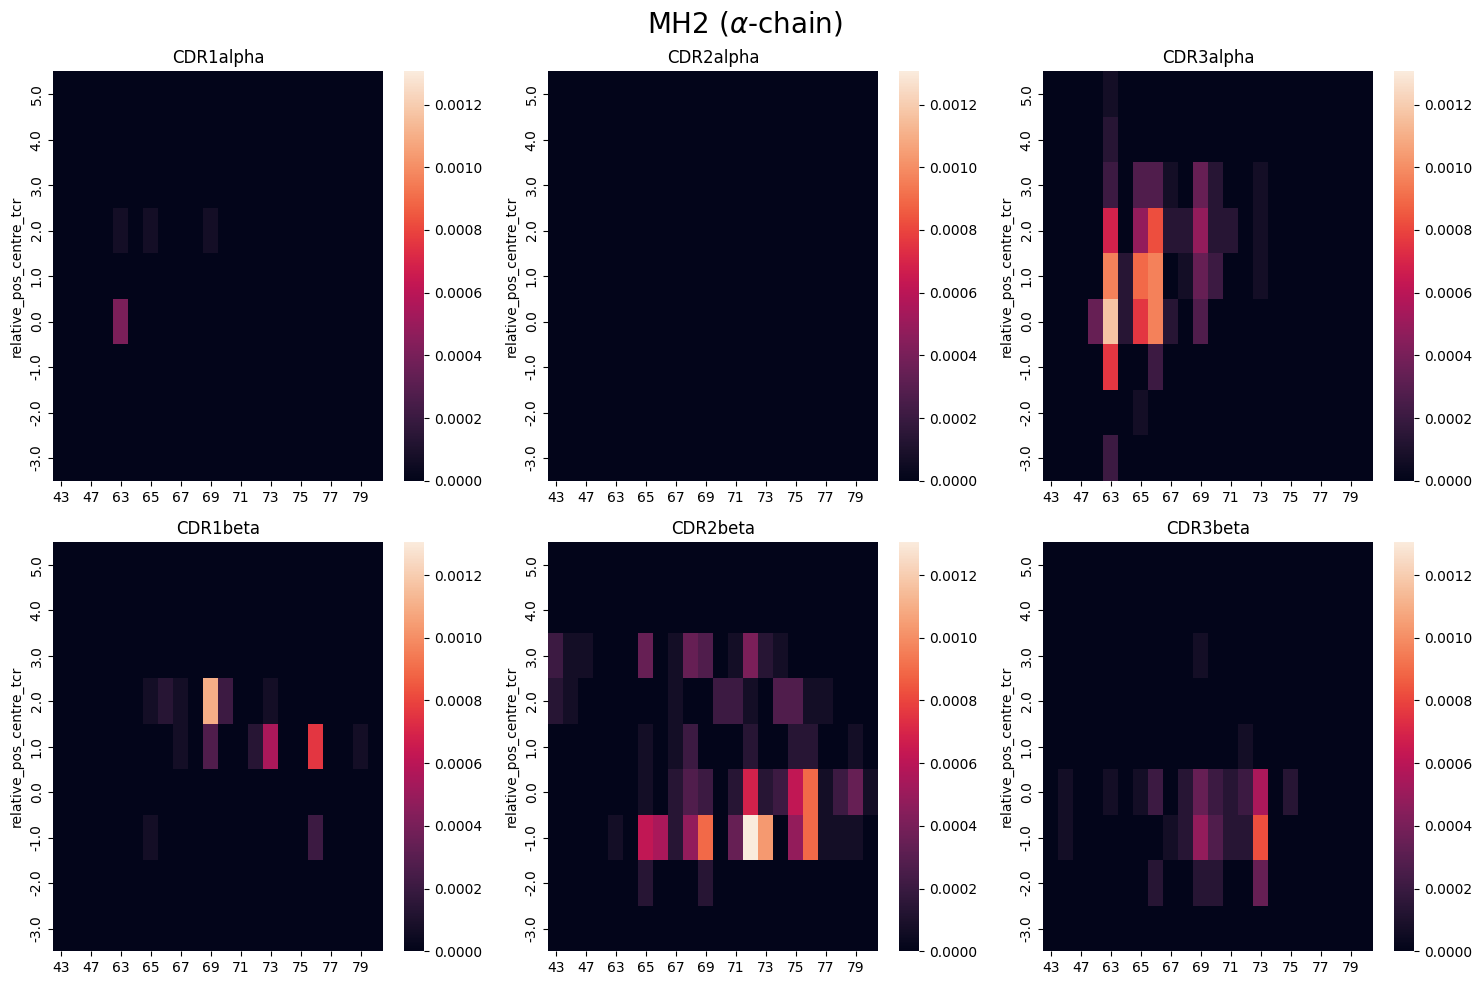

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle(r'MH2 ($\alpha$-chain)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'mhc_chain1')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

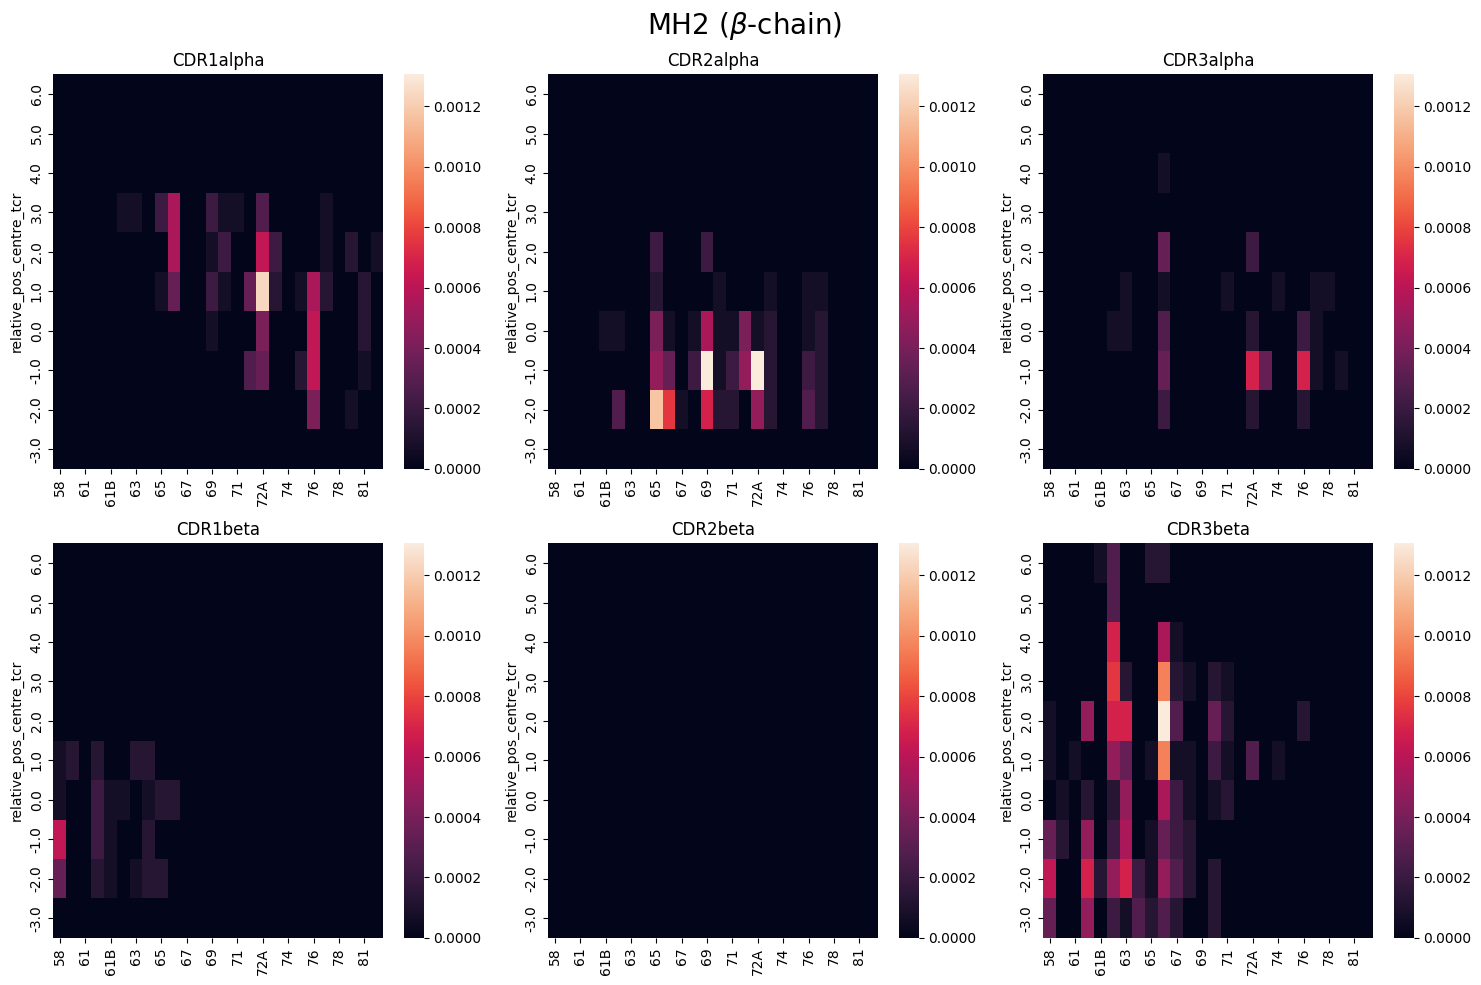

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle(r'MH2 ($\beta$-chain)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'mhc_chain2')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()